In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [148]:
df = pd.read_csv("crude-oil-price.csv")
df

,date,price,percentChange,change
0,1983-03-30T00:00:00,29.27,NaN,NaN
1,1983-04-04T00:00:00,30.63,4.646396,1.36
2,1983-05-02T00:00:00,30.25,-1.240614,-0.38
3,1983-06-01T00:00:00,31.38,3.735537,1.13
4,1983-07-01T00:00:00,32.00,1.975781,0.62
...,...,...,...,...
464,2021-11-01T00:00:00,65.85,-19.479090,-15.93
465,2021-12-01T00:00:00,74.88,13.712984,9.03
466,2022-01-03T00:00:00,86.49,15.504808,11.61
467,2022-02-01T00:00:00,95.72,10.671754,9.23


In [149]:
# Checking th information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 469 entries, 0 to 468
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           469 non-null    object 
 1   price          469 non-null    float64
 2   percentChange  468 non-null    float64
 3   change         468 non-null    float64
dtypes: float64(3), object(1)
memory usage: 14.8+ KB


In [150]:
# Checking the data shape
df.shape

(469, 4)

In [151]:
# checking for null values
df.isnull().sum()

,0
date,0
price,0
percentChange,1
change,1


In [152]:
# removing the null values

df.dropna(inplace = True)

In [153]:
# Basicc information of Dataset
df.describe()

,price,percentChange,change
count,468.000000,468.000000,468.000000
mean,44.103269,0.838667,0.171068
std,28.398837,10.685748,4.954575
min,10.420000,-54.244861,-32.830000
25%,20.267500,-5.040127,-1.632500
50%,30.835000,0.956201,0.280000
75%,63.662500,6.511568,2.317500
max,140.000000,88.375796,16.650000


In [154]:
df.head()

,date,price,percentChange,change
1,1983-04-04T00:00:00,30.63,4.646396,1.36
2,1983-05-02T00:00:00,30.25,-1.240614,-0.38
3,1983-06-01T00:00:00,31.38,3.735537,1.13
4,1983-07-01T00:00:00,32.00,1.975781,0.62
5,1983-08-01T00:00:00,31.59,-1.281250,-0.41


In [155]:
# Sorted Values of data set
df.sort_values('date' , inplace = True)

In [156]:
# Adding Date feature

df['Date'] = pd.to_datetime(df['date'])
df.set_index('Date', inplace=True)
df

,date,price,percentChange,change
Date,,,,
1983-04-04,1983-04-04T00:00:00,30.63,4.646396,1.36
1983-05-02,1983-05-02T00:00:00,30.25,-1.240614,-0.38
1983-06-01,1983-06-01T00:00:00,31.38,3.735537,1.13
1983-07-01,1983-07-01T00:00:00,32.00,1.975781,0.62
1983-08-01,1983-08-01T00:00:00,31.59,-1.281250,-0.41
...,...,...,...,...
2021-11-01,2021-11-01T00:00:00,65.85,-19.479090,-15.93
2021-12-01,2021-12-01T00:00:00,74.88,13.712984,9.03
2022-01-03,2022-01-03T00:00:00,86.49,15.504808,11.61


Exploratory Data Analysis


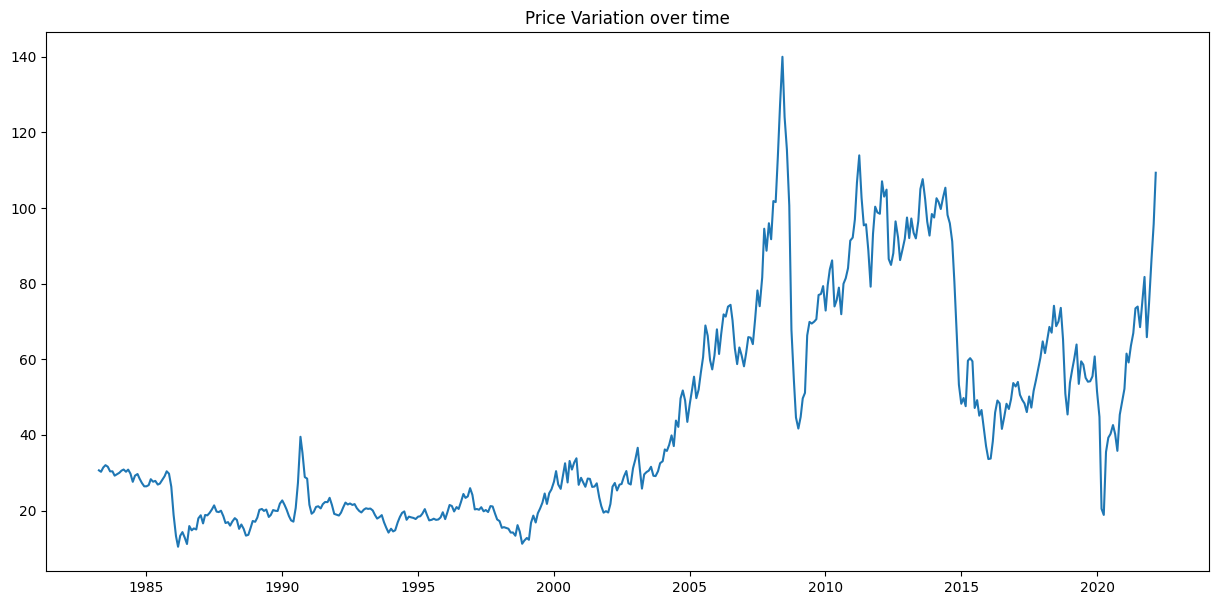

In [157]:
# Price Variation over a period of time
plt.figure(figsize = (15,7))
plt.plot(df['price'])
plt.title("Price Variation over time")
plt.show()

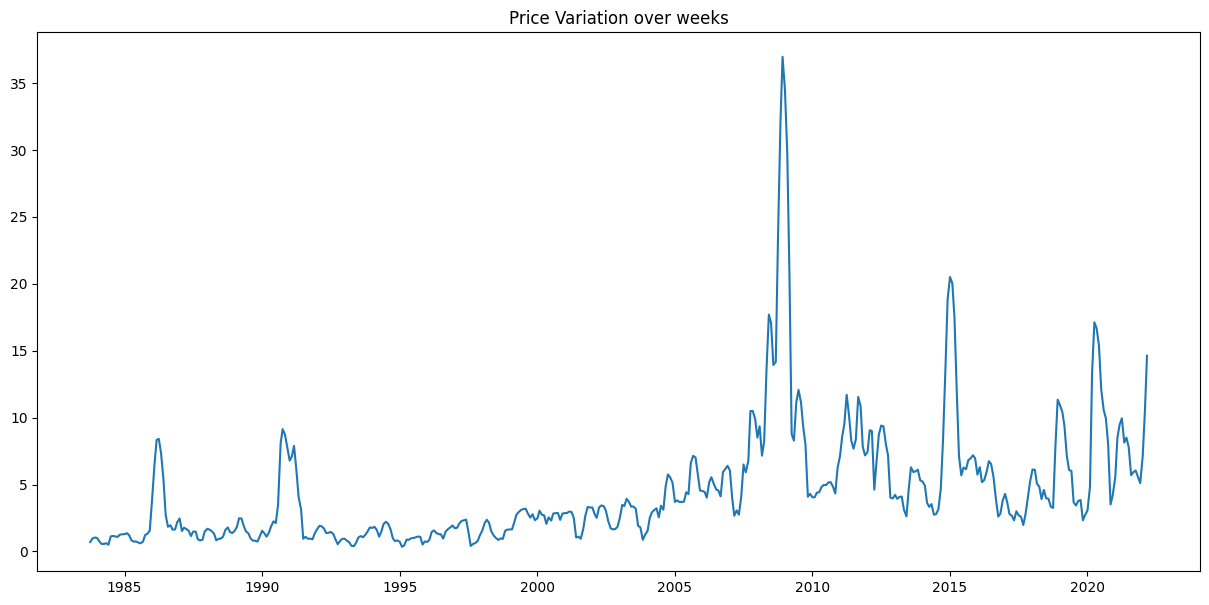

In [158]:
# Price Variaion over weeks

plt.figure(figsize = (15,7))
plt.plot(df['price'].rolling(7).std())
plt.title("Price Variation over weeks")
plt.show()

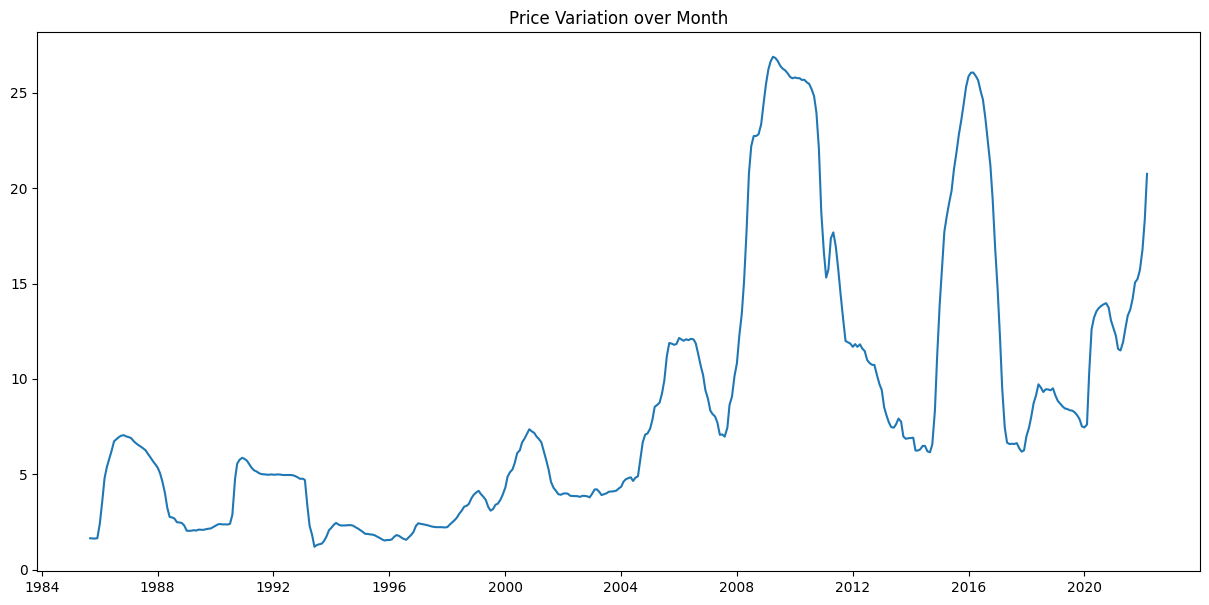

In [159]:
# Price Variation over month

plt.figure(figsize = (15,7))
plt.plot(df['price'].rolling(30).std())
plt.title("Price Variation over Month")
plt.show()

                  price  percentChange    change
price          1.000000       0.078724  0.118036
percentChange  0.078724       1.000000  0.824839
change         0.118036       0.824839  1.000000


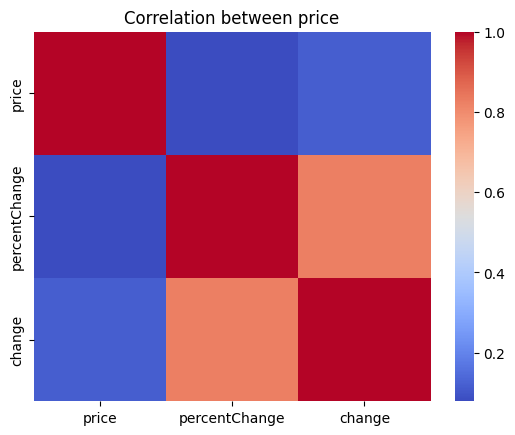

In [160]:
# Correlation between different feilds

print(df.corr(numeric_only = True))
plt.title("Correlation between price")
sns.heatmap(df.corr(numeric_only = True), cmap = 'coolwarm')
plt.show()


Text(0.5, 1.0, 'Variation of price with month')

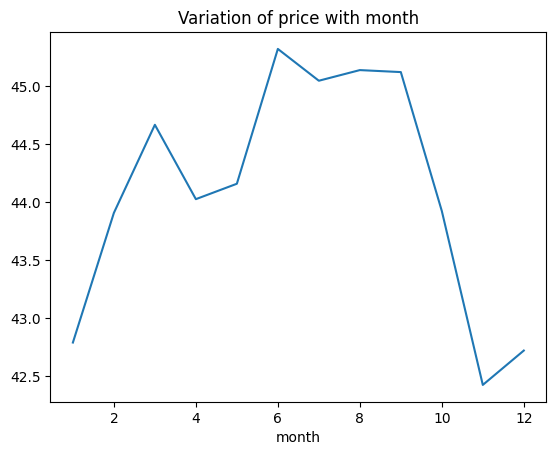

In [161]:
# Variation of price with month

df['month'] = df.index.month
df.groupby('month')['price'].mean().plot()
plt.title("Variation of price with month")

Text(0.5, 1.0, 'Variation of price with year')

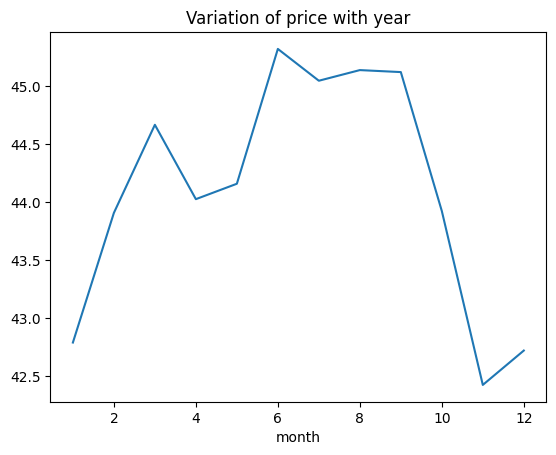

In [162]:
# Variation of price with year

df['year'] = df.index.year
df.groupby('month')['price'].mean().plot()
plt.title("Variation of price with year")

<Axes: >

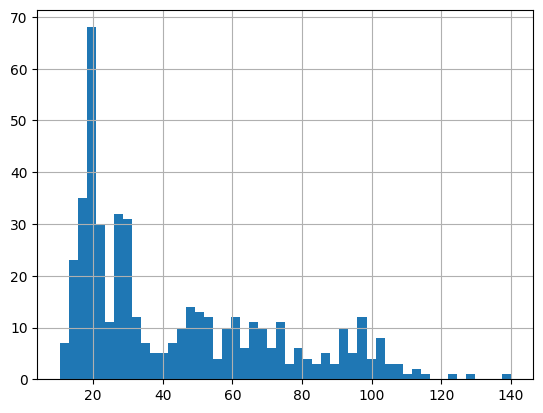

In [163]:
# Price trend

df['price'].hist(bins = 50)

In [164]:
fig = px.scatter_3d(df , x = 'price' , y = 'month' , z = 'year' , color = 'price')
fig.show()

In [165]:
fig = px.scatter_matrix(df,dimensions=['price','month','year'])
fig.show()

In [166]:
fig = px.bar(df , x = 'month' , y = 'price' , color = 'month')
fig.show()

Setting up data for model evaluation

In [167]:
# Setting up the data for ML model evaluation

df.drop('date',inplace = True,axis = 1)

In [168]:
df

,price,percentChange,change,month,year
Date,,,,,
1983-04-04,30.63,4.646396,1.36,4,1983
1983-05-02,30.25,-1.240614,-0.38,5,1983
1983-06-01,31.38,3.735537,1.13,6,1983
1983-07-01,32.00,1.975781,0.62,7,1983
1983-08-01,31.59,-1.281250,-0.41,8,1983
...,...,...,...,...,...
2021-11-01,65.85,-19.479090,-15.93,11,2021
2021-12-01,74.88,13.712984,9.03,12,2021
2022-01-03,86.49,15.504808,11.61,1,2022


Feature Engineering

In [169]:
df['target'] = df['price'].shift(-1)
# It creates a new column of target which predicts tommorrow price using today's price
# Aaj an bhav thi kal no bhav aape

In [170]:
df['Lag_1'] = df['price'].shift(1)  # gets the daily data trends(for daily analysis)
# Shift(1) : Moves data upside (Kal na bhav thi aaj no bhav batave)
df['Lag_7'] = df['price'].shift(7)  # gets the price for the oil on the same dahy of last week (for weekly analysis)

In [171]:
df['rolling_7'] = df['price'].shift(1).rolling(7).mean() # captures the trend and vulnerablitites of last 7 days
df['rolling_std_7'] = df['price'].shift(1).rolling(7).std()

In [172]:
df

,price,percentChange,change,month,year,target,Lag_1,Lag_7,rolling_7,rolling_std_7
Date,,,,,,,,,,
1983-04-04,30.63,4.646396,1.36,4,1983,30.25,NaN,NaN,NaN,NaN
1983-05-02,30.25,-1.240614,-0.38,5,1983,31.38,30.63,NaN,NaN,NaN
1983-06-01,31.38,3.735537,1.13,6,1983,32.00,30.25,NaN,NaN,NaN
1983-07-01,32.00,1.975781,0.62,7,1983,31.59,31.38,NaN,NaN,NaN
1983-08-01,31.59,-1.281250,-0.41,8,1983,30.36,32.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2021-11-01,65.85,-19.479090,-15.93,11,2021,74.88,81.78,63.58,71.891429,6.049263
2021-12-01,74.88,13.712984,9.03,12,2021,86.49,65.85,66.93,72.215714,5.571421
2022-01-03,86.49,15.504808,11.61,1,2022,95.72,74.88,73.47,73.351429,5.105146


In [173]:
df.dropna(inplace = True)

In [174]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

Creating 2 diffrent models for testing

In [175]:
model = LinearRegression()
model_1 = RandomForestRegressor(n_estimators=200)

In [176]:
X = df.drop(['price','target'] , axis= 1)
Y = df['target']

In [192]:
# Splitting the data into trainig and testing

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2 , random_state = 20 , shuffle = False)

In [178]:
model.fit(X_train,Y_train)
model_1.fit(X_train,Y_train)

RandomForestRegressor(n_estimators=200)

In [193]:
# Building a predictive system

y_pred = model.predict(X_test)
y_pred_1 = model_1.predict(X_test)

In [180]:
# Linear Regression Model

print(mean_absolute_error(Y_test,y_pred))
print(mean_squared_error(Y_test,y_pred))
print(r2_score(Y_test,y_pred))

5.178583234812834
47.64645512346714
0.7963127050897236


In [181]:
# Random Forest Regressor

print(mean_absolute_error(Y_test,y_pred_1))
print(mean_squared_error(Y_test,y_pred_1))
print(r2_score(Y_test,y_pred_1))

7.918849456521734
115.32790078654884
0.5069763725754487


Model Prediction Analysis

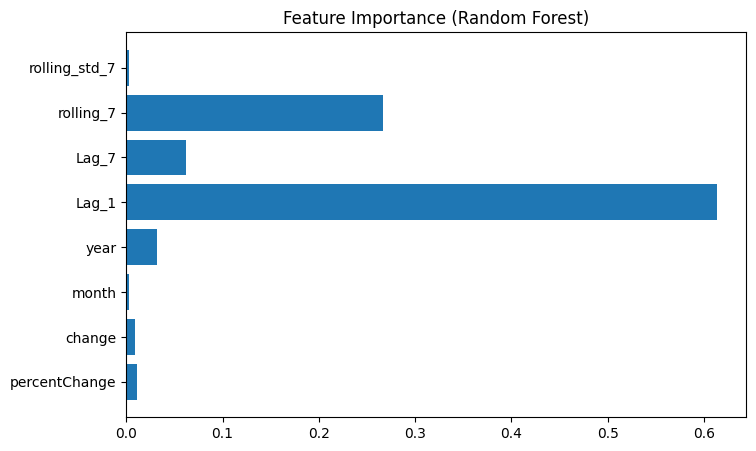

In [182]:
# Now lets compare actual and predicted values


plt.figure(figsize=(8,5))
plt.barh(X_train.columns, model_1.feature_importances_)
plt.title("Feature Importance (Random Forest)")
plt.show()

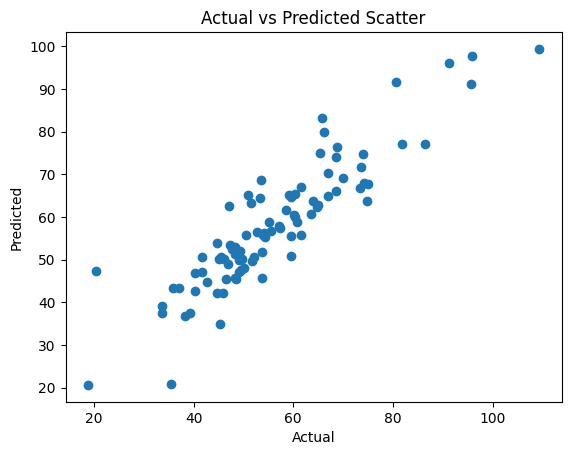

In [183]:
plt.scatter(Y_test, y_pred )
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Scatter")
plt.show()

<BarContainer object of 92 artists>

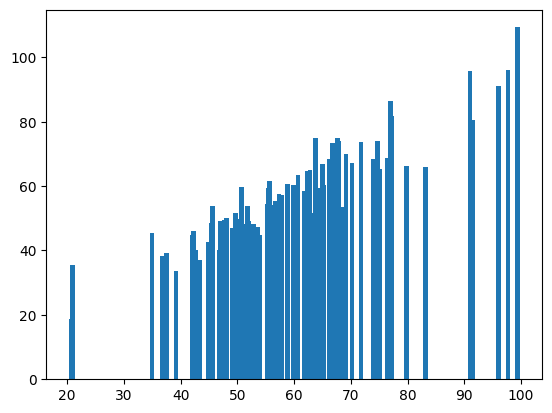

In [184]:
plt.bar(y_pred , Y_test)

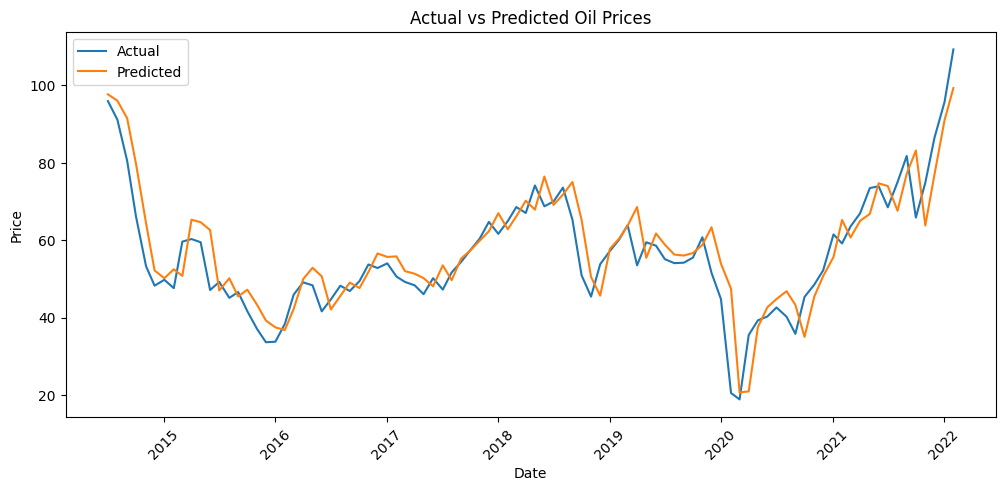

In [185]:
plt.figure(figsize=(12,5))

plt.plot(Y_test.index, Y_test, label='Actual')
plt.plot(Y_test.index, y_pred, label='Predicted')

plt.title("Actual vs Predicted Oil Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.xticks(rotation=45)

plt.show()

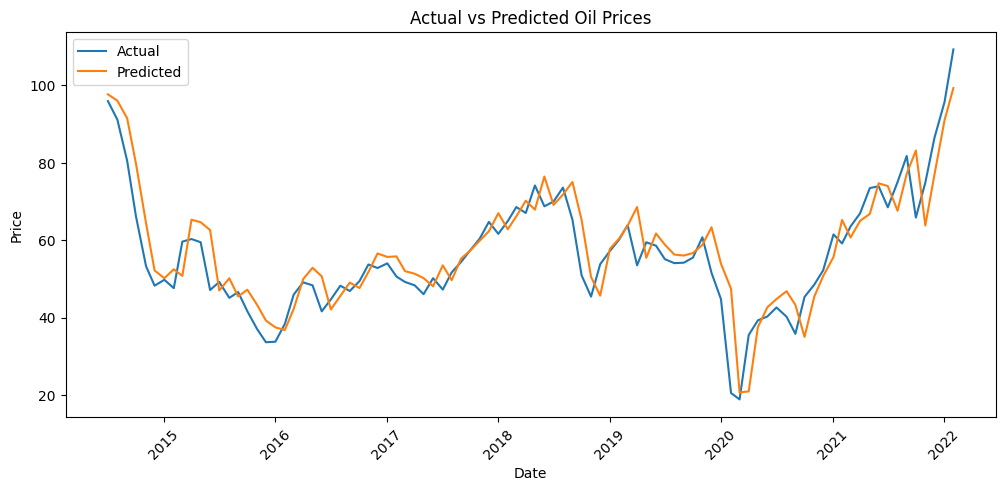

In [186]:
# Error Plotting

plt.figure(figsize=(12,5))

plt.plot(Y_test.index, Y_test, label='Actual')
plt.plot(Y_test.index, y_pred, label='Predicted')

plt.title("Actual vs Predicted Oil Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.xticks(rotation=45)

plt.show()

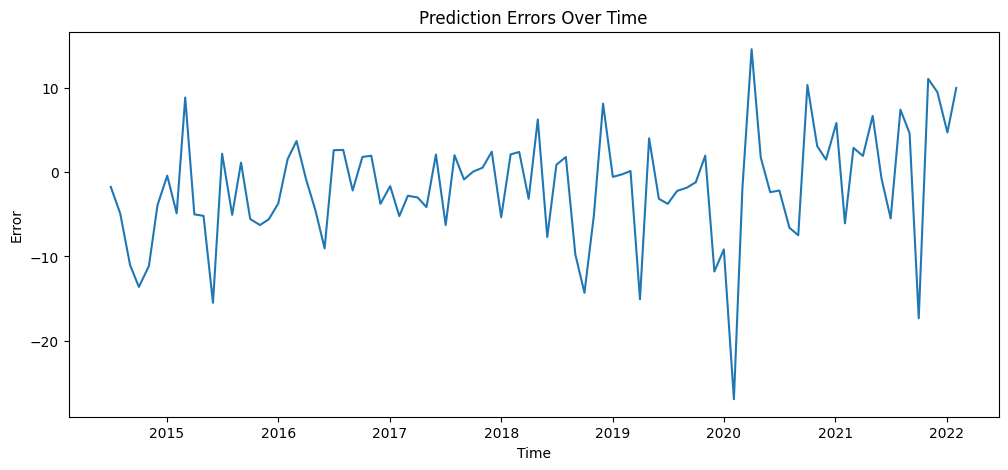

In [187]:
# Error Calculation

errors = Y_test - y_pred

plt.figure(figsize=(12,5))
plt.plot(errors)
plt.title("Prediction Errors Over Time")
plt.xlabel("Time")
plt.ylabel("Error")

plt.show()

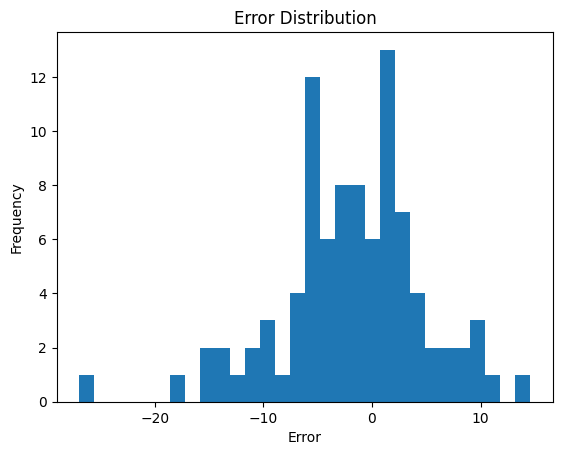

In [188]:
# Error calculation

plt.hist(errors, bins=30)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [189]:
# Comparison Table for the models

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [
        mean_absolute_error(Y_test, y_pred),
        mean_absolute_error(Y_test, y_pred_1)
    ],
    'MSE': [
        mean_squared_error(Y_test, y_pred),
        mean_squared_error(Y_test, y_pred_1)
    ],
    'R2': [
        r2_score(Y_test, y_pred),
        r2_score(Y_test, y_pred_1)
    ]
})

print(results)

               Model       MAE         MSE        R2
0  Linear Regression  5.178583   47.646455  0.796313
1      Random Forest  7.918849  115.327901  0.506976


In [190]:
# Prediction for Model

x_input = [[0.981997,0.30,3,1984,30.55,31.59,30.240000,0.757980]]
prediction = model.predict(x_input)

print(prediction)

[30.52619138]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



Conclusion Report:

- This project analyzed crude oil price trends and built predictive models using historical data.

- Linear Regression achieved the best performance with an R² score of around 0.79, indicating strong linear dependency between past and future prices. Random Forest performed worse due to the small dataset size and the highly linear nature of the data.

- Feature engineering using lag variables and rolling statistics played a crucial role in improving model performance. Lag features, especially lag_1, showed strong correlation with the target, highlighting short-term dependencies in oil prices.

- Overall, the model successfully captures short-term price movements, though performance can be improved with larger datasets and more external features such as economic indicators.
